# Import

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import pointbiserialr

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


# Datasource
https://docs.google.com/document/d/1B3Itxfko-DzyzQlF4_Qc73aSTrcPyLpaySRRyD7-EY0/edit?tab=t.0

In [179]:
df = pd.read_csv("/home/darknetdoll/projects/kink_research/database/cgl_BKS_data.csv")
df = df.drop(columns='role_Nazis')
pd.set_option("display.max_info_columns", df.shape[1])

## Review Schema

In [180]:
# df.info(verbose=True, show_counts=True)
list(df.columns)

['age',
 'cgl',
 'openness',
 'consciensiousness',
 'extroversion',
 'neuroticism',
 'agreeableness',
 'powerlessness',
 'diagnosis',
 'sexual_interest_variety',
 'role_Atheletes',
 'role_Babysitter',
 'role_Catboys',
 'role_Catgirls',
 'role_Celebrities',
 'role_Cheerleaders',
 'role_Criminals',
 'role_Doctors',
 'role_Escorts/prostitutes',
 'role_Geishas',
 'role_Gigolos',
 'role_Gynecologists',
 'role_Librarians',
 'role_Maids',
 'role_Nuns',
 'role_Nurses',
 'role_Priests',
 'role_Scientists',
 'role_Strippers',
 'role_Students',
 'role_Teachers',
 'agegap',
 'progression',
 'regression',
 'soft_erotic_ enthusiastic consent',
 'soft_erotic_affection',
 'soft_erotic_caretaker/caretakee dynamics',
 'soft_erotic_clear',
 'soft_erotic_cuddling',
 'soft_erotic_energy work',
 'soft_erotic_romance',
 'soft_erotic_sensual healing',
 'soft_erotic_tantra',
 'soft_erotic_therapeutic sexual experiences',
 'youfeelmost',
 'otherfeel1most']

# CGL Personality

## CGL Sample Size

In [182]:
# Replace CGL NaN values with 0 and create a boolean flag for CGL presence.
df['cgl'] = df['cgl'].fillna(0)
df['cgl_flag']=(df['cgl'] > 0).astype(bool)

# Extracting DF for CGL and non-CGL records.
cgl_df = df[df['cgl_flag'] == True]
non_cgl_df = df[df['cgl_flag'] == False]

In [183]:
cgl_count=cgl_df.shape[0]
non_cgl_count=non_cgl_df.shape[0]
print(
    "Total records: ",
    df.shape[0],
    "\nTotal CGL positive records: ", 
    cgl_count,
    '({:.2f}%)'.format(cgl_count/df.shape[0]*100),
    "\nTotal CGL negative records: ",
    non_cgl_count,
)
# df[df.cgl_flag ==True][['cgl_flag','cgl']].shape[0]

Total records:  15503 
Total CGL positive records:  2845 (18.35%) 
Total CGL negative records:  12658


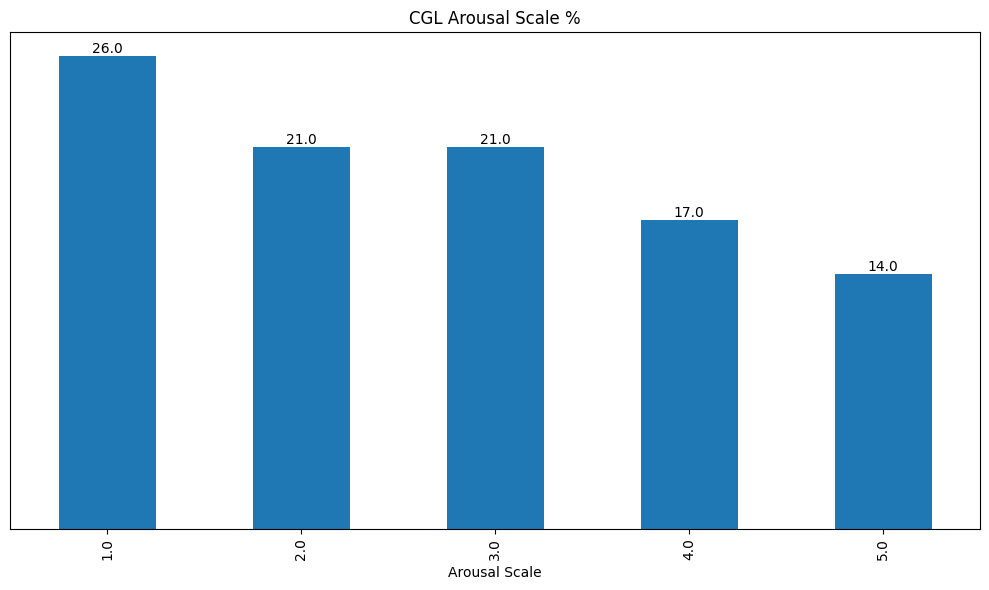

In [184]:
# Review CGL Arousal Scale distribution.
# df[df.cgl_flag==True]['cgl'].value_counts(normalize=True).round(2)*100

ax=(cgl_df["cgl"].value_counts(normalize=True).round(2) * 100).sort_index().plot(
    kind="bar", figsize=(10, 6), title="CGL Value Distribution"
)
# Formatting
ax.bar_label(ax.containers[0], fmt='%.1f')  # Add value labels
ax.get_yaxis().set_visible(False)
plt.xlabel("Arousal Scale")
plt.title("CGL Arousal Scale %")
plt.tight_layout()
plt.show()

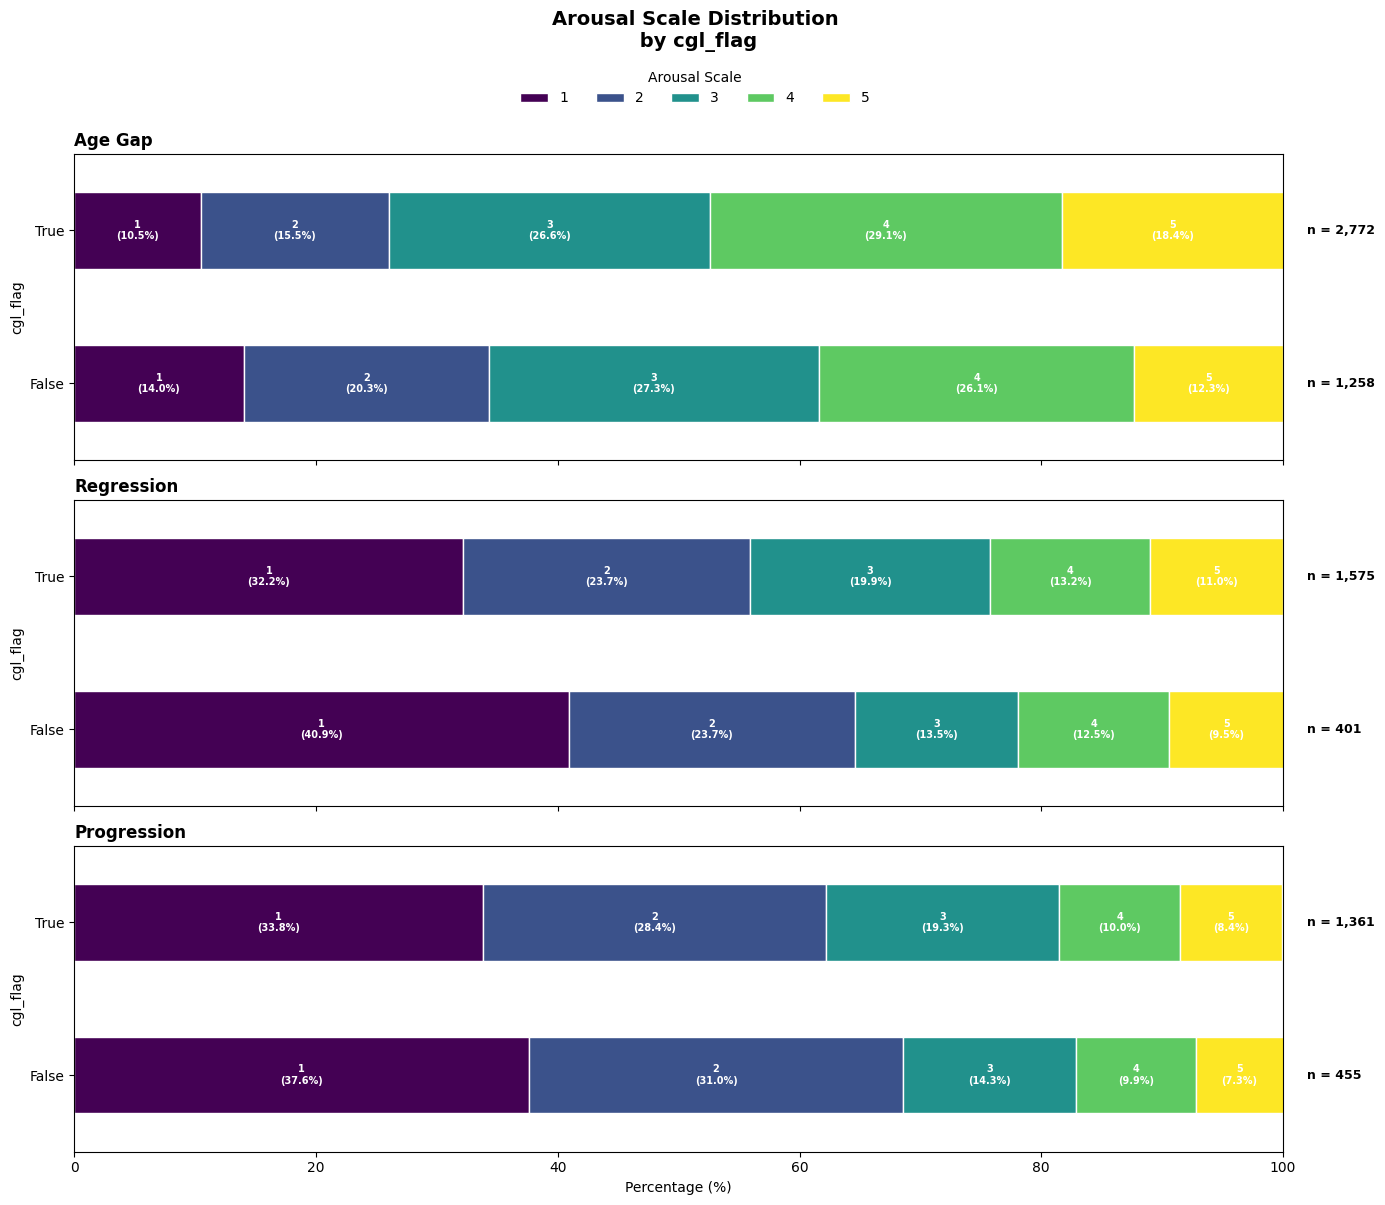

In [185]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_arousal_distribution(ax, df, col, title):
    """Plot arousal scale distribution for `col`, sliced by cgl_flag."""
    # Filter NaN and 0
    df_filtered = df.dropna(subset=[col]).copy()
    df_filtered = df_filtered[df_filtered[col] != 0]
    df_filtered[col] = df_filtered[col].astype(int)

    # Cross-tab (each row sums to 100%)
    flag_pivot = (
        pd.crosstab(df_filtered['cgl_flag'], df_filtered[col], normalize='index')
        .mul(100)
        .round(1)
    )

    flag_pivot.plot(
        kind='barh', stacked=True, ax=ax,
        cmap='viridis', edgecolor='white', legend=False,
    )

    ax.set_title(title, fontweight='bold', loc='left')
    ax.set_xlim(0, 100)
    ax.set_ylabel('cgl_flag')

    # Segment labels
    for i, container in enumerate(ax.containers):
        scale_value = flag_pivot.columns[i]
        labels = [f'{scale_value}\n({v:.1f}%)' if v > 3 else '' for v in flag_pivot.iloc[:, i]]
        ax.bar_label(container, labels=labels, label_type='center',
                     fontsize=7, color='white', fontweight='bold')

    # n= labels on the right
    counts_per_flag = df_filtered['cgl_flag'].value_counts()
    for i, flag in enumerate(flag_pivot.index):
        ax.text(
            1.02, i, f'n = {counts_per_flag[flag]:,}',
            transform=ax.get_yaxis_transform(),
            ha='left', va='center',
            fontsize=9, fontweight='bold',
        )

    return flag_pivot


# Define the metrics: (column_name, display_title)
metrics = [
    ('agegap', 'Age Gap'),
    ('regression', 'Regression'),
    ('progression', 'Progression'), 
]

# Create stacked subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 4 * len(metrics)), sharex=True)

last_pivot = None
for ax, (col, title) in zip(axes, metrics):
    last_pivot = plot_arousal_distribution(ax, df, col, title)

axes[-1].set_xlabel('Percentage (%)')

# Single shared legend at the top of the figure
fig.legend(
    handles=axes[0].containers,
    labels=[str(c) for c in last_pivot.columns],
    title='Arousal Scale',
    bbox_to_anchor=(0.5, 0.96),
    loc='upper center',
    ncol=len(last_pivot.columns),
    frameon=False,
)

fig.suptitle('Arousal Scale Distribution\n by cgl_flag',
             fontweight='bold', fontsize=14, y=1.0)

plt.tight_layout()
plt.subplots_adjust(top=0.88, right=0.92)
plt.show()


## CGL Roles Distribution

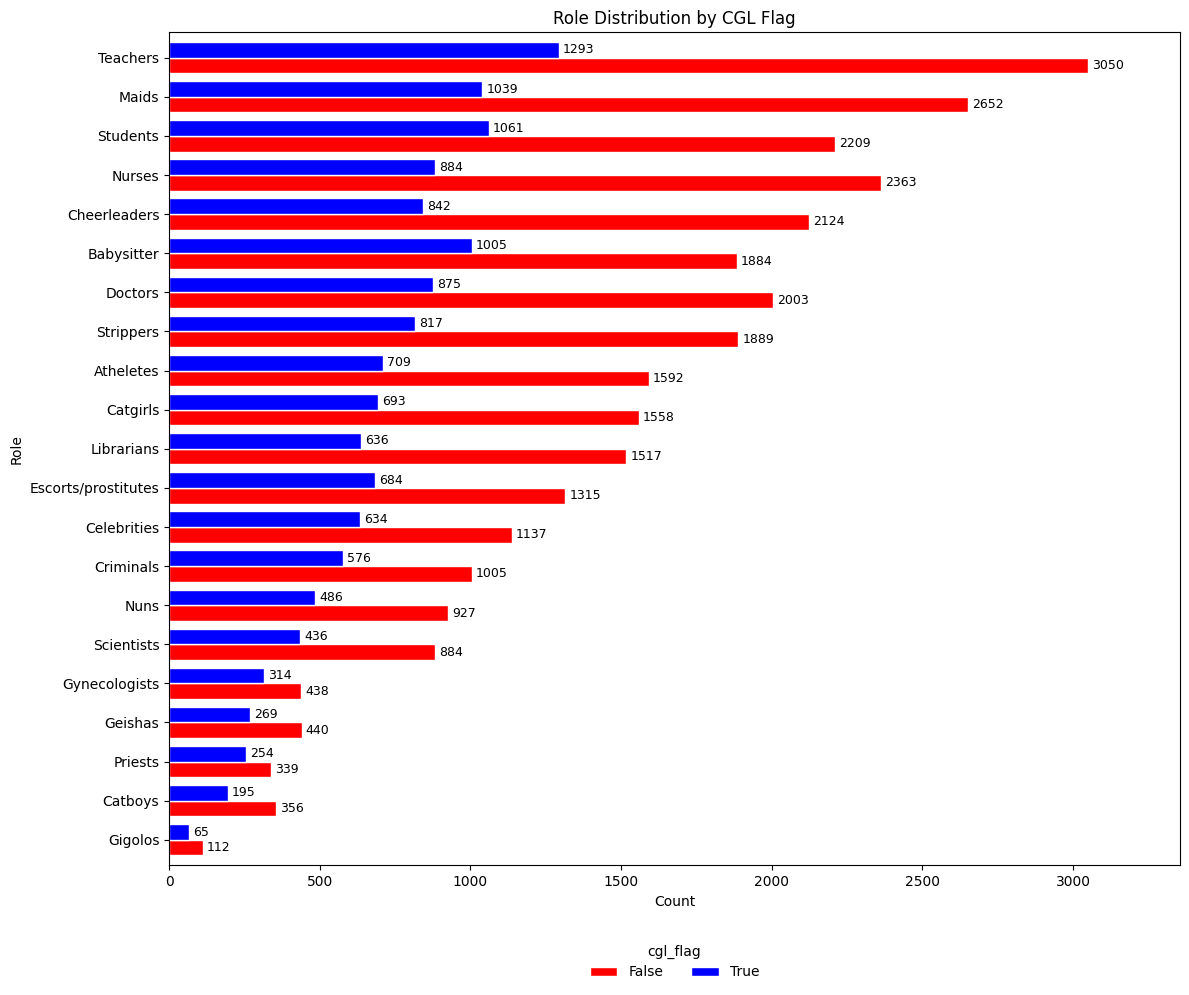

In [139]:
# Use the FULL dataframe (df), not the filtered cgl_df
role_cols = df.filter(like='role_').columns.tolist()
role_by_flag = df.groupby('cgl_flag')[role_cols].sum().T

role_by_flag = role_by_flag.sort_index(axis=1).fillna(0).astype(int)
role_by_flag.index = role_by_flag.index.str.replace('role_', '', regex=False)
role_by_flag = role_by_flag.loc[role_by_flag.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(12, 10))
role_by_flag.plot(
    kind='barh',
    ax=ax,
    color=['red', 'blue'],
    edgecolor='white',
    width=0.8,
)

ax.set_title('Role Distribution by CGL Flag')
ax.set_xlabel('Count')
ax.set_ylabel('Role')
ax.legend(title='cgl_flag', bbox_to_anchor=(0.5, -0.08), loc='upper center', ncol=2, frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

xmax = role_by_flag.values.max()
if xmax > 0:
    ax.set_xlim(0, xmax * 1.1)

plt.tight_layout()
plt.show()


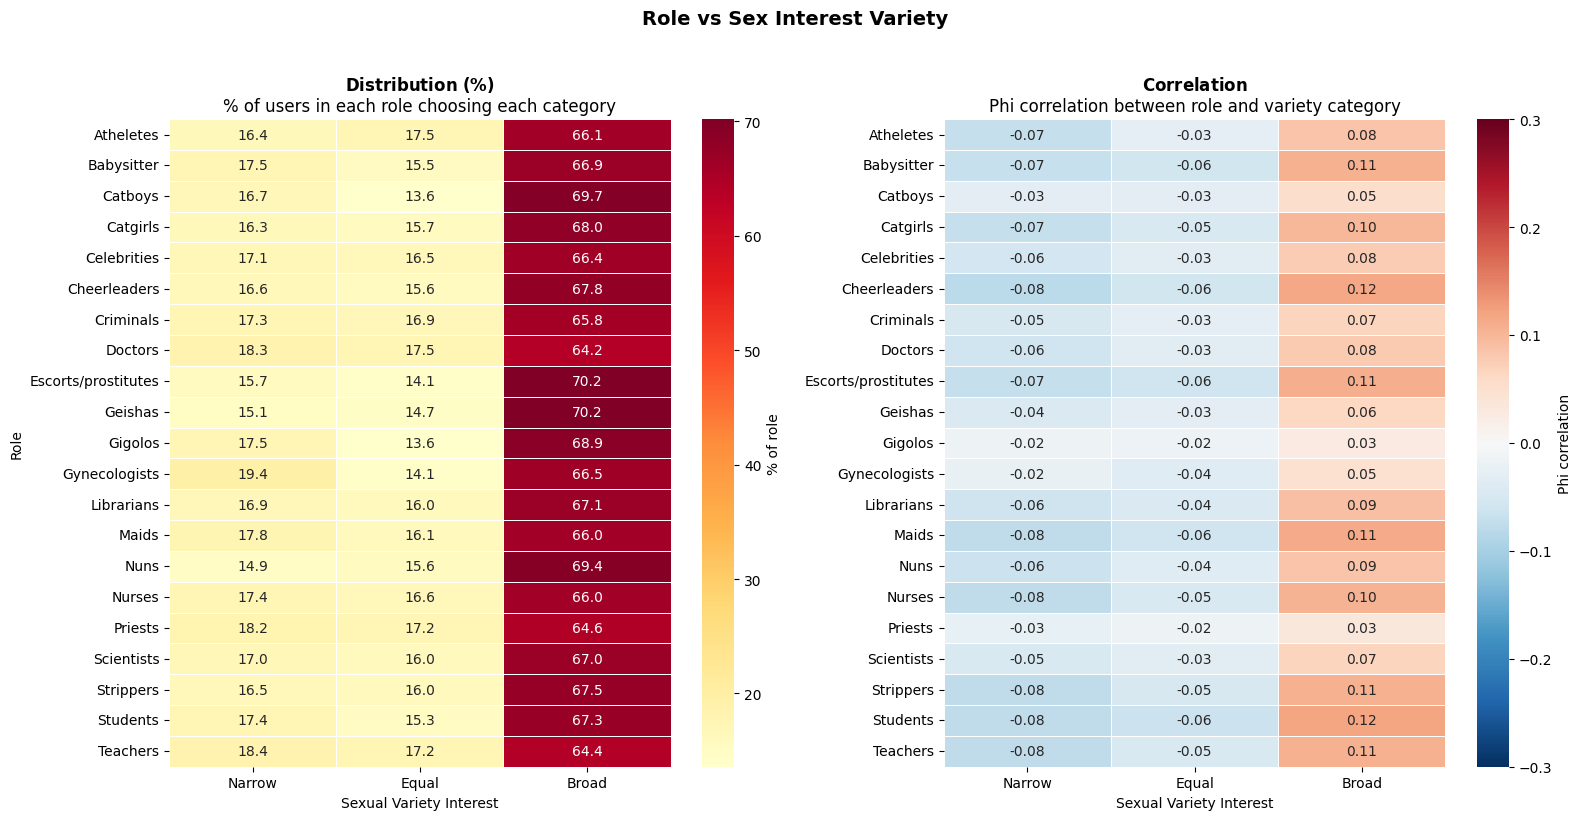

In [ ]:
# ===== Collapse variety to 3 levels =====
variety_3_map = {
    'Very narrow': 'Narrow',
    'A little narrow': 'Narrow',
    'Somewhat narrow': 'Narrow',
    'Equally narrow and broad': 'Equal',
    'A little broad': 'Broad',
    'Somewhat broad': 'Broad',
    'Very broad': 'Broad',
}
df['variety_3'] = df['sexual_interest_variety'].map(variety_3_map)
variety_order = ['Narrow', 'Equal', 'Broad']

role_cols = df.filter(like='role_').columns.tolist()

# ===== LEFT: % distribution =====
rows = []
for r_col in role_cols:
    subset = df[df[r_col] == 1]
    if len(subset) > 0:
        dist = (
            subset['variety_3']
            .value_counts(normalize=True)
            .mul(100)
            .round(1)
        )
        dist.name = r_col.replace('role_', '')
        rows.append(dist)

pct_data = (
    pd.concat(rows, axis=1).T.fillna(0)
    .reindex(columns=variety_order, fill_value=0)
    .sort_index()
)

# ===== RIGHT: phi correlation =====
variety_dummies = pd.get_dummies(df['variety_3']).reindex(
    columns=variety_order, fill_value=0
)

corr_matrix = pd.DataFrame(
    index=[c.replace('role_', '') for c in role_cols],
    columns=variety_order,
    dtype=float,
)
for r_col in role_cols:
    for v_cat in variety_order:
        corr_matrix.loc[r_col.replace('role_', ''), v_cat] = df[r_col].corr(variety_dummies[v_cat])

corr_matrix = corr_matrix.astype(float).sort_index()

# ===== Plot side by side =====
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(
    pct_data, annot=True, fmt='.1f',
    cmap='YlOrRd', cbar_kws={'label': '% of role'},
    linewidths=0.5, linecolor='white', ax=axes[0],
)
axes[0].set_title(r"$\bf{Distribution\ (\%)}$" "\n% of users in each role choosing each category")
axes[0].set_xlabel('Sexual Variety Interest')
axes[0].set_ylabel('Role')
plt.setp(axes[0].get_xticklabels(), rotation=0, ha='center')
plt.setp(axes[0].get_yticklabels(), rotation=0)

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.3,
    cbar_kws={'label': 'Phi correlation'},
    linewidths=0.5, linecolor='white', ax=axes[1],
)
axes[1].set_title(r"$\bf{Correlation}$" "\nPhi correlation between role and variety category")
axes[1].set_xlabel('Sexual Variety Interest')
axes[1].set_ylabel('')
plt.setp(axes[1].get_xticklabels(), rotation=0, ha='center')
plt.setp(axes[1].get_yticklabels(), rotation=0)

fig.suptitle('Role vs Sex Interest Variety', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## CGL Emotional Erotic Desires 

In [ ]:
### Not many ppl answered --> not useful

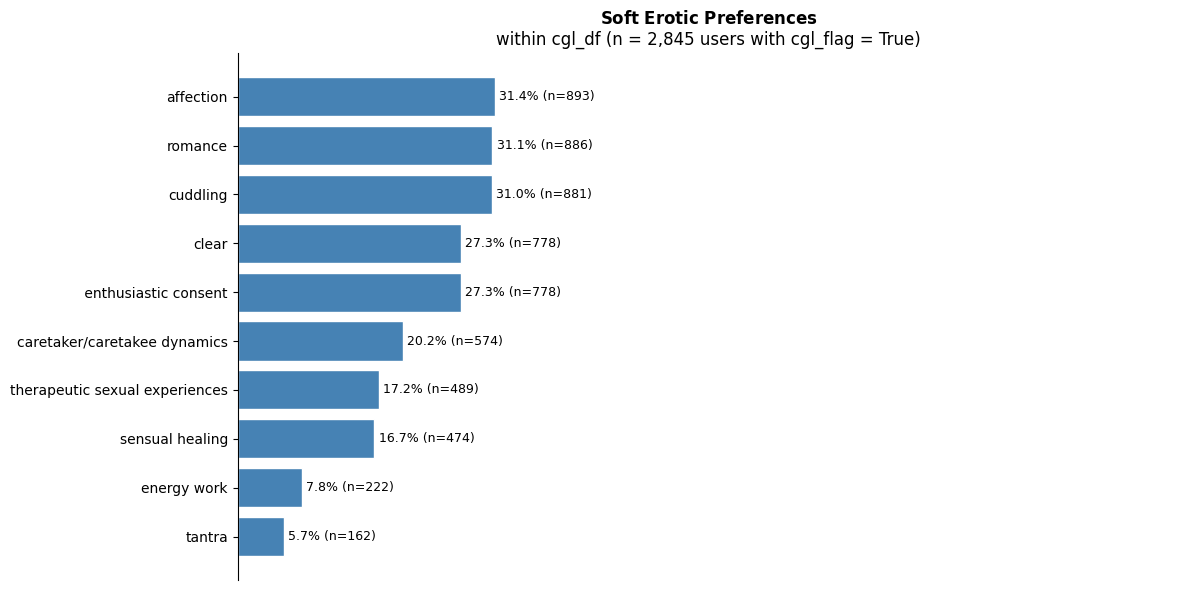

In [ ]:
soft_erotic_cols = cgl_df.filter(like='soft_erotic_').columns.tolist()

# Calculate counts and percentages
data = pd.DataFrame({
    'pct': (cgl_df[soft_erotic_cols].mean() * 100).round(1),
    'count': cgl_df[soft_erotic_cols].sum().astype(int),
})

# Strip prefix
data.index = data.index.str.replace(r'^(soft_erotic_)+', '', regex=True)

# Sort ascending (highest at top of horizontal bar)
data = data.sort_values('pct', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, max(6, len(data) * 0.35)))
ax.barh(data.index, data['pct'], color='steelblue', edgecolor='white')

ax.set_title(
    r"$\bf{Soft\ Erotic\ Preferences}$"
    f"\nwithin cgl_df (n = {len(cgl_df):,} users with cgl_flag = True)"
)

# Hide x-axis (ticks, label, and surrounding spines)
ax.set_xticks([])
ax.set_xlabel('')
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Data labels: "85.3% (n=2,361)"
labels = [f'{p:.1f}% (n={n:,})' for p, n in zip(data['pct'], data['count'])]
ax.bar_label(ax.containers[0], labels=labels, padding=3, fontsize=9)

# Extra room on the right so labels don't get clipped
ax.set_xlim(0, 115)

plt.tight_layout()
plt.show()


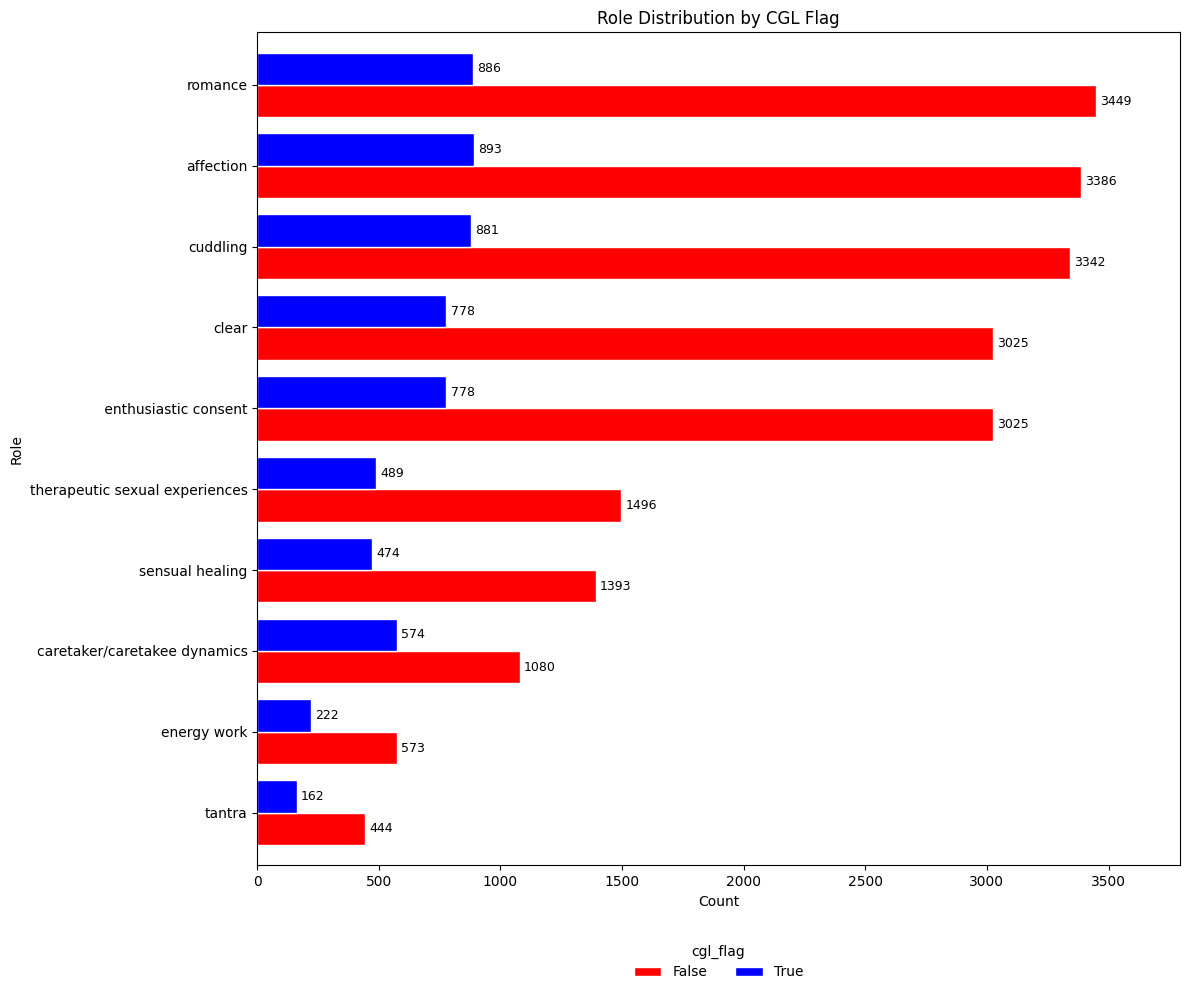

In [142]:
# Use the FULL dataframe (df), not the filtered cgl_df
role_cols = df.filter(like='soft_erotic_').columns.tolist()
role_by_flag = df.groupby('cgl_flag')[role_cols].sum().T

role_by_flag = role_by_flag.sort_index(axis=1).fillna(0).astype(int)
role_by_flag.index = role_by_flag.index.str.replace('soft_erotic_', '', regex=False)
role_by_flag = role_by_flag.loc[role_by_flag.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(12, 10))
role_by_flag.plot(
    kind='barh',
    ax=ax,
    color=['red', 'blue'],
    edgecolor='white',
    width=0.8,
)

ax.set_title('Role Distribution by CGL Flag')
ax.set_xlabel('Count')
ax.set_ylabel('Role')
ax.legend(title='cgl_flag', bbox_to_anchor=(0.5, -0.08), loc='upper center', ncol=2, frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

xmax = role_by_flag.values.max()
if xmax > 0:
    ax.set_xlim(0, xmax * 1.1)

plt.tight_layout()
plt.show()


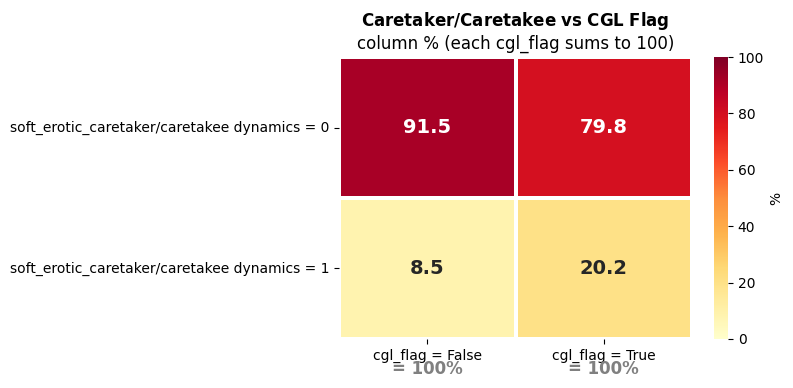

In [ ]:
# === Adjust to match your column ===
care_col = 'soft_erotic_caretaker/caretakee dynamics'
# ===================================

# Column-normalized: each cgl_flag column sums to 100%
breakdown = (
    pd.crosstab(df[care_col], df['cgl_flag'], normalize='columns')
    .mul(100)
    .round(1)
    .sort_index(axis=1)
    .sort_index(axis=0)
)

breakdown.index = [f'{care_col} = {v}' for v in breakdown.index]
breakdown.columns = [f'cgl_flag = {c}' for c in breakdown.columns]

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    breakdown,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': '%'},
    linewidths=1.5, linecolor='white',
    ax=ax,
    vmin=0, vmax=100,
    annot_kws={'fontsize': 14, 'fontweight': 'bold'},
)

# Column totals at the bottom (always 100)
for j, col_total in enumerate(breakdown.sum(axis=0)):
    ax.text(
        j + 0.5, breakdown.shape[0] + 0.15,
        f'= {col_total:.0f}%',
        va='top', ha='center',
        fontsize=12, fontweight='bold', color='gray',
    )

ax.set_title(r"$\bf{Caretaker/Caretakee\ vs\ CGL\ Flag}$" "\ncolumn % (each cgl_flag sums to 100)")
ax.set_xlabel('')
ax.set_ylabel('')
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


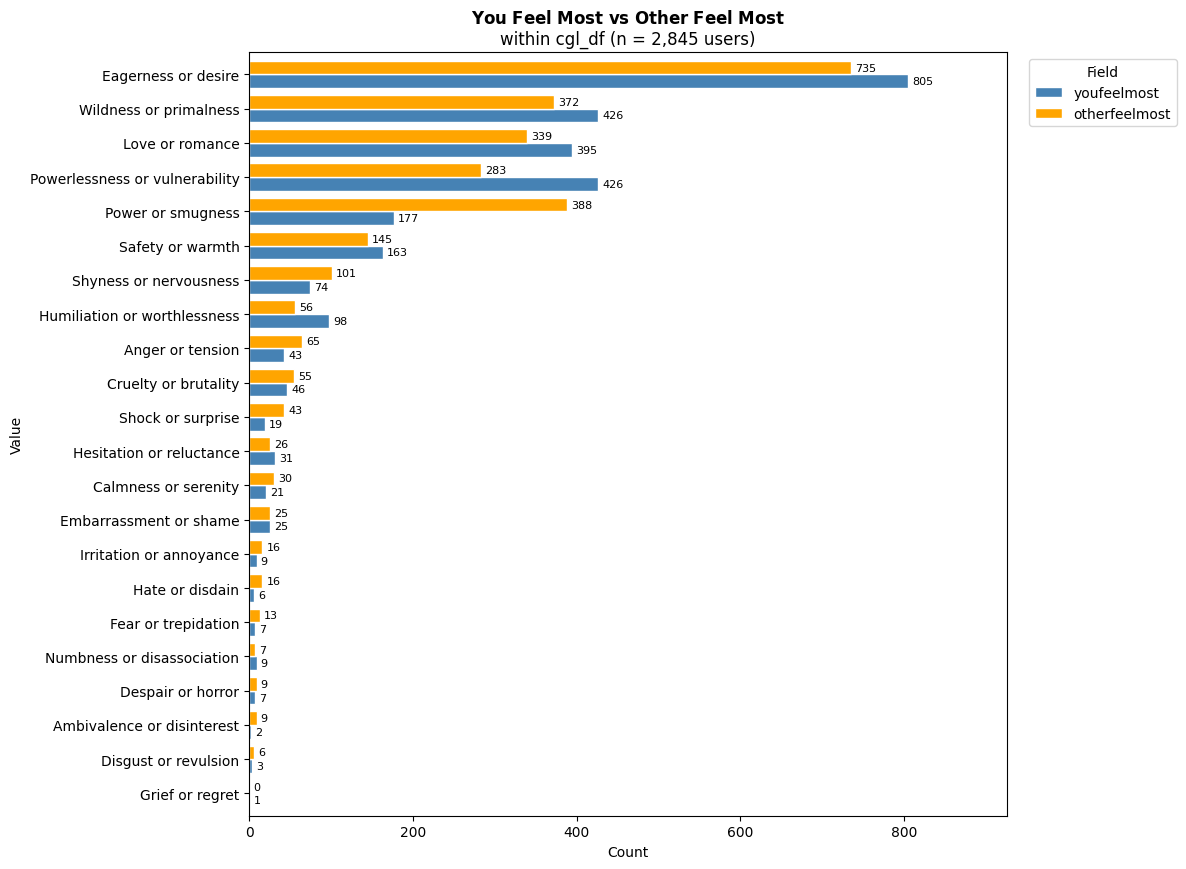

In [ ]:
combined = pd.DataFrame({
    'youfeelmost': cgl_df['youfeelmost'].value_counts(),
    'otherfeelmost': cgl_df['otherfeel1most'].value_counts(),
}).fillna(0).astype(int)

# Sort by total count across both fields (ascending → highest at top)
combined = combined.loc[combined.sum(axis=1).sort_values(ascending=True).index]

# Plot grouped horizontal bar
fig, ax = plt.subplots(figsize=(12, max(6, len(combined) * 0.4)))
combined.plot(
    kind='barh',
    ax=ax,
    color=['steelblue', 'orange'],
    edgecolor='white',
    width=0.8,
)

ax.set_title(
    r"$\bf{You\ Feel\ Most\ vs\ Other\ Feel\ Most}$"
    f"\nwithin cgl_df (n = {len(cgl_df):,} users)"
)
ax.set_xlabel('Count')
ax.set_ylabel('Value')

# Count labels at the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=8)

ax.legend(title='Field', bbox_to_anchor=(1.02, 1), loc='upper left')

xmax = combined.values.max()
if xmax > 0:
    ax.set_xlim(0, xmax * 1.15)

plt.tight_layout()
plt.show()


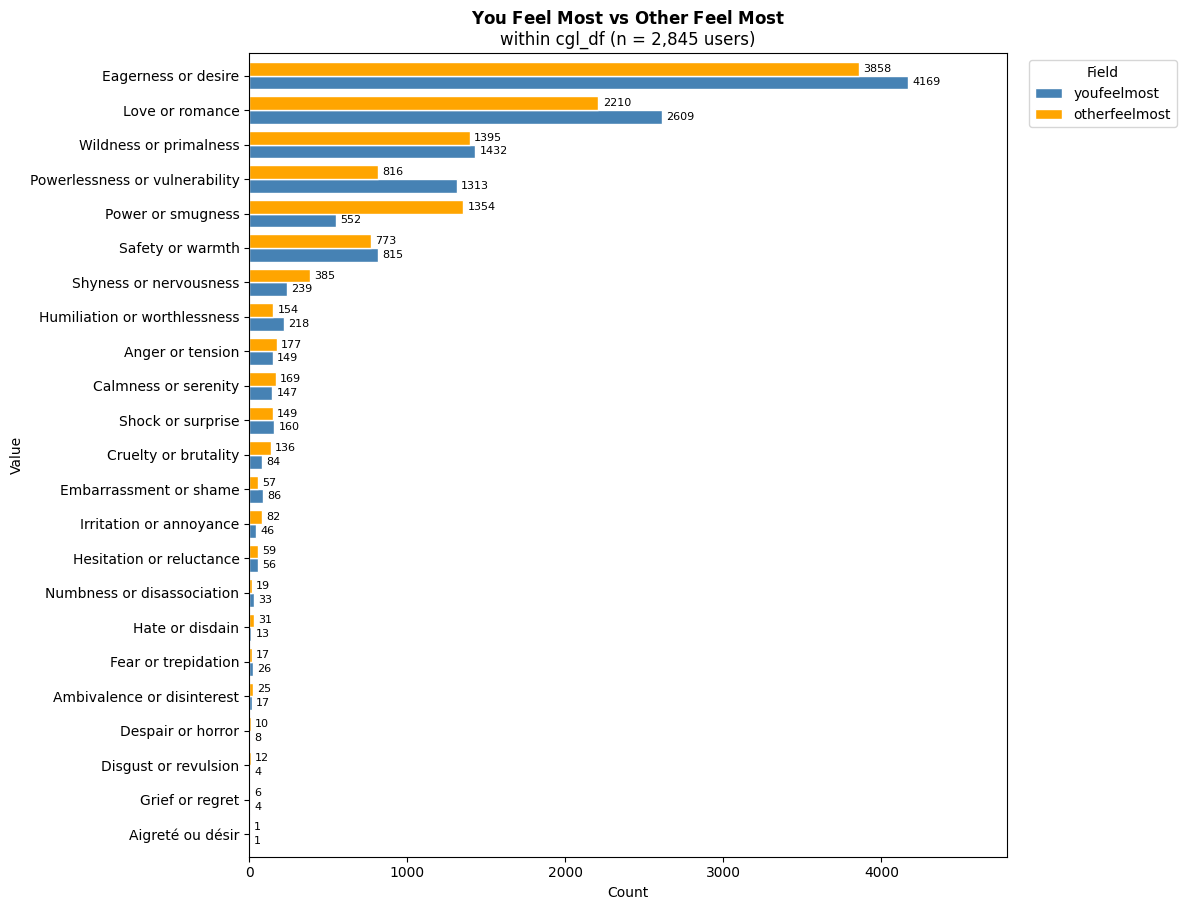

In [ ]:
# Count occurrences in each field
combined = pd.DataFrame({
    'youfeelmost': non_cgl_df['youfeelmost'].value_counts(),
    'otherfeelmost': non_cgl_df['otherfeel1most'].value_counts(),
}).fillna(0).astype(int)

# Sort by total count across both fields (ascending → highest at top)
combined = combined.loc[combined.sum(axis=1).sort_values(ascending=True).index]

# Plot grouped horizontal bar
fig, ax = plt.subplots(figsize=(12, max(6, len(combined) * 0.4)))
combined.plot(
    kind='barh',
    ax=ax,
    color=['steelblue', 'orange'],
    edgecolor='white',
    width=0.8,
)

ax.set_title(
    r"$\bf{You\ Feel\ Most\ vs\ Other\ Feel\ Most}$"
    f"\nwithin cgl_df (n = {len(cgl_df):,} users)"
)
ax.set_xlabel('Count')
ax.set_ylabel('Value')

# Count labels at the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=8)

ax.legend(title='Field', bbox_to_anchor=(1.02, 1), loc='upper left')

xmax = combined.values.max()
if xmax > 0:
    ax.set_xlim(0, xmax * 1.15)

plt.tight_layout()
plt.show()


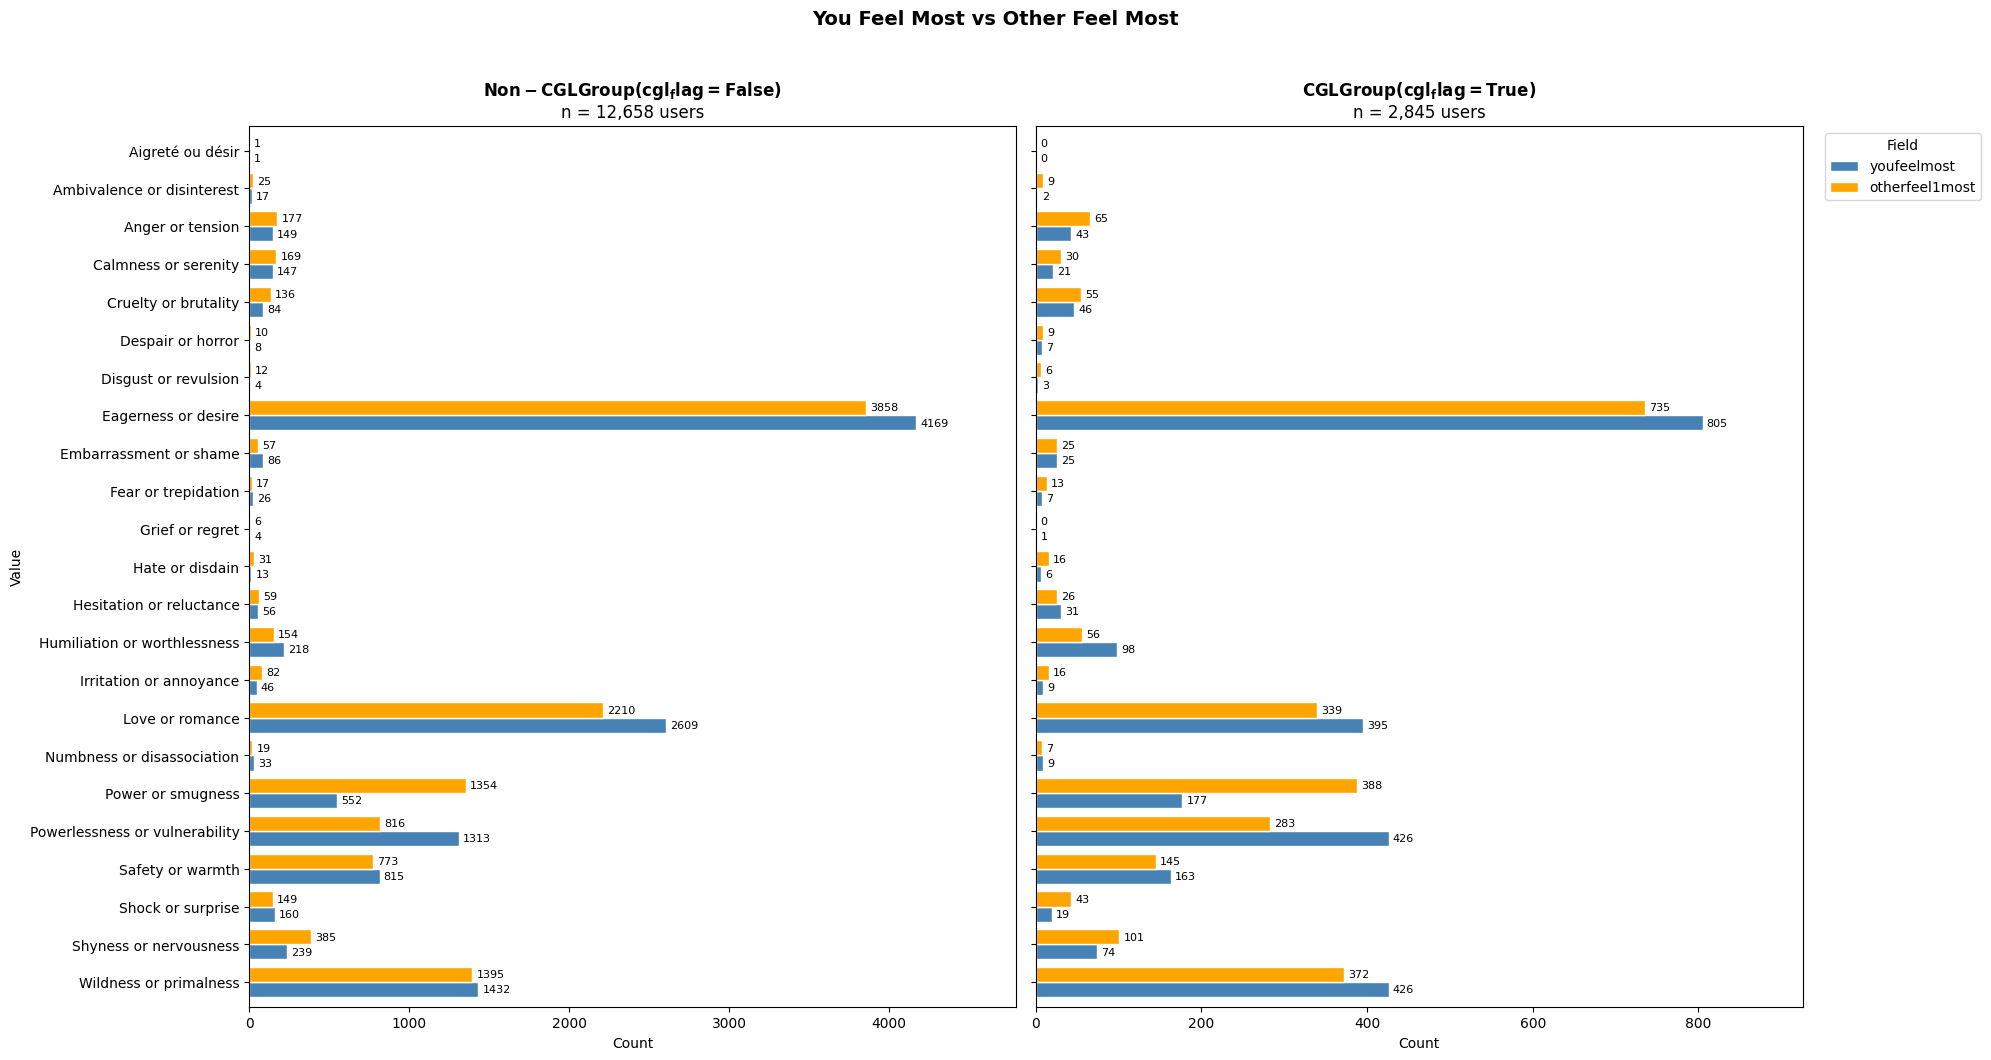

In [ ]:
def get_combined(df_subset):
    return pd.DataFrame({
        'youfeelmost': df_subset['youfeelmost'].value_counts(),
        'otherfeel1most': df_subset['otherfeel1most'].value_counts(),
    }).fillna(0).astype(int)

# Get all unique values across both subsets/fields, alphabetically
all_values = sorted(set(
    df['youfeelmost'].dropna().unique().tolist()
    + df['otherfeel1most'].dropna().unique().tolist()
))

# Reverse so 'A' appears at the top of the horizontal bar (barh draws first item at the bottom)
shared_index = all_values[::-1]

non_cgl_combined = get_combined(non_cgl_df).reindex(shared_index, fill_value=0)
cgl_combined = get_combined(cgl_df).reindex(shared_index, fill_value=0)

# Plot side by side with shared y-axis
fig, axes = plt.subplots(
    1, 2,
    figsize=(20, max(8, len(shared_index) * 0.45)),
    sharey=True,
)

for ax, data, title, n in [
    (axes[0], non_cgl_combined, 'Non-CGL Group (cgl_flag = False)', len(non_cgl_df)),
    (axes[1], cgl_combined,     'CGL Group (cgl_flag = True)',      len(cgl_df)),
]:
    data.plot(
        kind='barh', ax=ax,
        color=['steelblue', 'orange'],
        edgecolor='white', width=0.8,
        legend=(ax is axes[1]),   # legend only on the right plot
    )
    ax.set_title(f"$\\bf{{{title}}}$\nn = {n:,} users")
    ax.set_xlabel('Count')

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=8)

    xmax = data.values.max()
    if xmax > 0:
        ax.set_xlim(0, xmax * 1.15)

axes[0].set_ylabel('Value')
axes[1].set_ylabel('')

# Move legend out of the way (to the right of the right plot)
axes[1].legend(title='Field', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.suptitle('You Feel Most vs Other Feel Most', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


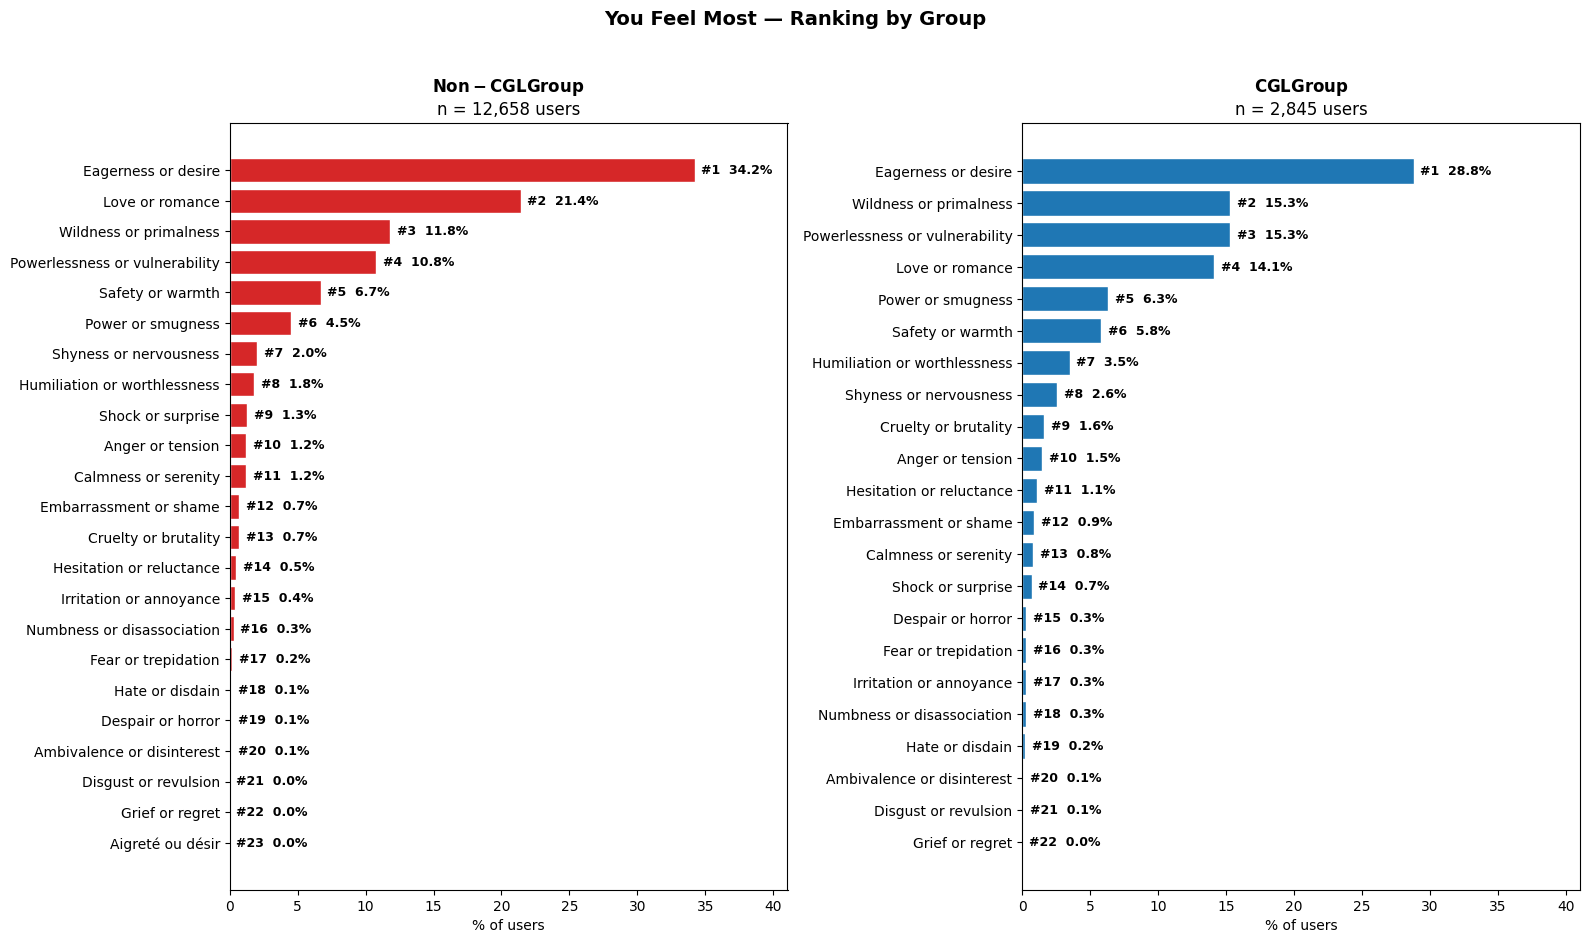

In [ ]:
def get_pct_ranked(df_subset):
    return (
        df_subset['youfeelmost']
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .sort_values(ascending=True)   # ascending → highest at top of barh
    )

non_cgl_pct = get_pct_ranked(non_cgl_df)
cgl_pct = get_pct_ranked(cgl_df)

# Use a shared xlim so bar widths compare visually
shared_xmax = max(non_cgl_pct.max(), cgl_pct.max()) * 1.20

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, max(len(non_cgl_pct), len(cgl_pct)) * 0.4)))

for ax, pct, title, n, color in [
    (axes[0], non_cgl_pct, 'Non-CGL Group',  len(non_cgl_df), '#d62728'),
    (axes[1], cgl_pct,     'CGL Group',      len(cgl_df),     '#1f77b4'),
]:
    ax.barh(pct.index, pct.values, color=color, edgecolor='white')
    ax.set_title(f"$\\bf{{{title}}}$\nn = {n:,} users", fontsize=12)
    ax.set_xlabel('% of users')
    ax.set_xlim(0, shared_xmax)

    # Rank numbers + % values  ("#1  31.4%")
    n_items = len(pct)
    for i, (label, value) in enumerate(zip(pct.index, pct.values)):
        rank = n_items - i      # i=0 is the bottom, which is the lowest-ranked
        ax.text(value + 0.5, i, f'#{rank}  {value:.1f}%', va='center', fontsize=9, fontweight='bold')

axes[0].set_ylabel('')
axes[1].set_ylabel('')

fig.suptitle('You Feel Most — Ranking by Group', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
def rank_with_pct(df_subset):
    """Return list of 'value (X.X%)' strings ranked by frequency."""
    counts = df_subset['youfeelmost'].value_counts()
    total = counts.sum()
    return [f'{val} ({c/total*100:.1f}%)' for val, c in counts.items()]

non_cgl_ranked = rank_with_pct(non_cgl_df)
cgl_ranked = rank_with_pct(cgl_df)

# Pad the shorter list so both columns have equal length
max_len = max(len(non_cgl_ranked), len(cgl_ranked))
non_cgl_ranked += [''] * (max_len - len(non_cgl_ranked))
cgl_ranked += [''] * (max_len - len(cgl_ranked))

ranking_table = pd.DataFrame(
    {
        f'Non-CGL  (n={len(non_cgl_df):,})': non_cgl_ranked,
        f'CGL  (n={len(cgl_df):,})':         cgl_ranked,
    },
    index=[f'#{i+1}' for i in range(max_len)],
)
ranking_table.index.name = 'Rank'

ranking_table


,"Non-CGL (n=12,658)","CGL (n=2,845)"
Rank,,
#1,Eagerness or desire (34.2%),Eagerness or desire (28.8%)
#2,Love or romance (21.4%),Powerlessness or vulnerability (15.3%)
#3,Wildness or primalness (11.8%),Wildness or primalness (15.3%)
#4,Powerlessness or vulnerability (10.8%),Love or romance (14.1%)
#5,Safety or warmth (6.7%),Power or smugness (6.3%)
#6,Power or smugness (4.5%),Safety or warmth (5.8%)
#7,Shyness or nervousness (2.0%),Humiliation or worthlessness (3.5%)
#8,Humiliation or worthlessness (1.8%),Shyness or nervousness (2.6%)
#9,Shock or surprise (1.3%),Cruelty or brutality (1.6%)


In [175]:
def rank_with_pct(df_subset):
    """Return list of 'value (X.X%)' strings ranked by frequency."""
    counts = df_subset['otherfeel1most'].value_counts()
    total = counts.sum()
    return [f'{val} ({c/total*100:.1f}%)' for val, c in counts.items()]

non_cgl_ranked = rank_with_pct(non_cgl_df)
cgl_ranked = rank_with_pct(cgl_df)

# Pad the shorter list so both columns have equal length
max_len = max(len(non_cgl_ranked), len(cgl_ranked))
non_cgl_ranked += [''] * (max_len - len(non_cgl_ranked))
cgl_ranked += [''] * (max_len - len(cgl_ranked))

ranking_table = pd.DataFrame(
    {
        f'Non-CGL  (n={len(non_cgl_df):,})': non_cgl_ranked,
        f'CGL  (n={len(cgl_df):,})':         cgl_ranked,
    },
    index=[f'#{i+1}' for i in range(max_len)],
)
ranking_table.index.name = 'Rank'

ranking_table

,"Non-CGL (n=12,658)","CGL (n=2,845)"
Rank,,
#1,Eagerness or desire (32.4%),Eagerness or desire (26.8%)
#2,Love or romance (18.6%),Power or smugness (14.2%)
#3,Wildness or primalness (11.7%),Wildness or primalness (13.6%)
#4,Power or smugness (11.4%),Love or romance (12.4%)
#5,Powerlessness or vulnerability (6.9%),Powerlessness or vulnerability (10.3%)
#6,Safety or warmth (6.5%),Safety or warmth (5.3%)
#7,Shyness or nervousness (3.2%),Shyness or nervousness (3.7%)
#8,Anger or tension (1.5%),Anger or tension (2.4%)
#9,Calmness or serenity (1.4%),Humiliation or worthlessness (2.0%)


## Personality

In [ ]:
ocean_cols = ['openness', 'consciensiousness', 'extroversion',
              'neuroticism', 'agreeableness', 'powerlessness']

# Use the FULL df so cgl_flag has both True and False
assert df['cgl_flag'].nunique() > 1, "cgl_flag must have both True and False — use full df, not cgl_df"

results = []
for trait in ocean_cols:
    mask = df[trait].notna() & df['cgl_flag'].notna()

    # Skip if either side is constant
    x = df.loc[mask, 'cgl_flag'].astype(int)
    y = df.loc[mask, trait]
    if x.nunique() < 2 or y.nunique() < 2:
        print(f"Skipping {trait}: constant input")
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('error')   # turn remaining warnings into errors so we notice
        r, p = pointbiserialr(x, y)

    cgl_vals = df.loc[(df['cgl_flag'] == True) & df[trait].notna(), trait]
    non_cgl_vals = df.loc[(df['cgl_flag'] == False) & df[trait].notna(), trait]
    pooled_std = ((cgl_vals.std()**2 + non_cgl_vals.std()**2) / 2) ** 0.5
    cohens_d = (cgl_vals.mean() - non_cgl_vals.mean()) / pooled_std if pooled_std else 0

    results.append({
        'trait': trait,
        'mean_non_cgl': non_cgl_vals.mean(),
        'mean_cgl': cgl_vals.mean(),
        'r': r,
        'p_value': p,
        'cohens_d': cohens_d,
    })

results_df = pd.DataFrame(results).set_index('trait').round(2)
print(results_df)


                   mean_non_cgl  mean_cgl     r  p_value  cohens_d
trait                                                             
openness                   1.63      1.69  0.01     0.26      0.02
consciensiousness          1.28      1.20 -0.01     0.10     -0.03
extroversion              -1.29     -1.30 -0.00     0.95     -0.00
neuroticism                0.95      1.02  0.01     0.21      0.03
agreeableness              2.02      1.94 -0.01     0.17     -0.03
powerlessness              0.64      0.96  0.03     0.00      0.09


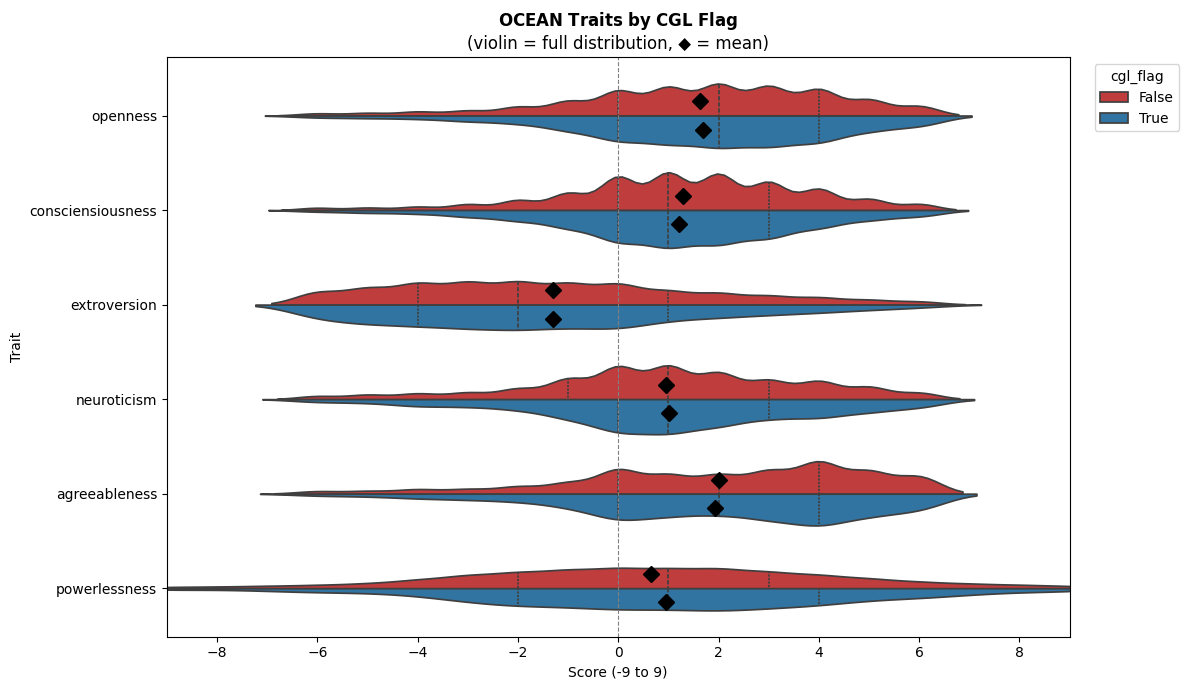

In [ ]:
long_data = df[ocean_cols + ['cgl_flag']].melt(
    id_vars='cgl_flag', var_name='trait', value_name='score'
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.violinplot(
    data=long_data,
    y='trait', x='score', hue='cgl_flag',
    split=True,                     # split each violin so True/False sit back-to-back
    inner='quart',                  # show quartile lines
    palette={False: '#d62728', True: '#1f77b4'},
    ax=ax,
)

# Overlay mean markers
means = df.groupby('cgl_flag')[ocean_cols].mean().T
for i, trait in enumerate(ocean_cols):
    ax.plot(means.loc[trait, False], i - 0.15, marker='D', color='black', markersize=8)
    ax.plot(means.loc[trait, True],  i + 0.15, marker='D', color='black', markersize=8)

ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title(r"$\bf{OCEAN\ Traits\ by\ CGL\ Flag}$" "\n(violin = full distribution, ◆ = mean)")
ax.set_xlabel('Score (-9 to 9)')
ax.set_ylabel('Trait')
ax.set_xlim(-9, 9)
ax.legend(title='cgl_flag', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



/tmp/ipykernel_1375592/3331180424.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


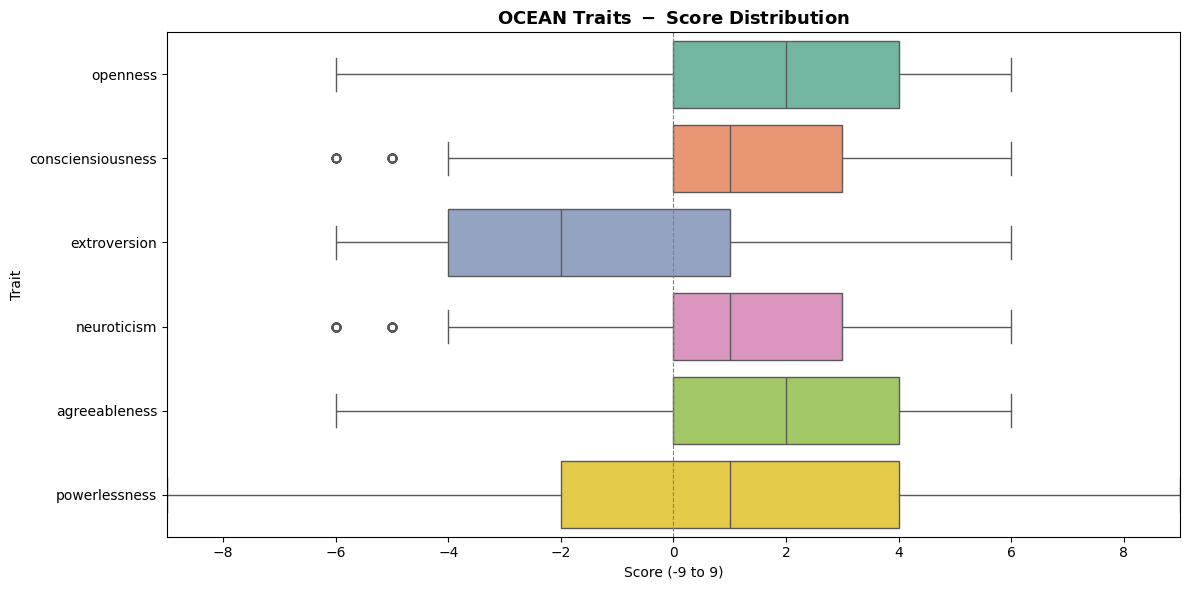

In [ ]:
ocean_cols = ['openness', 'consciensiousness', 'extroversion',
              'neuroticism', 'agreeableness', 'powerlessness']

# Reshape to long format for seaborn
long_data = cgl_df[ocean_cols].melt(var_name='trait', value_name='score')

# Plot horizontal box plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=long_data,
    y='trait',
    x='score',
    ax=ax,
    palette='Set2',
    showfliers=True,    # show outliers; set to False for a cleaner look
)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title(r"$\bf{OCEAN\ Traits\ -\ Score\ Distribution}$", fontsize=13)
ax.set_xlabel('Score (-9 to 9)')
ax.set_ylabel('Trait')
ax.set_xlim(-9, 9)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1375592/1754972734.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


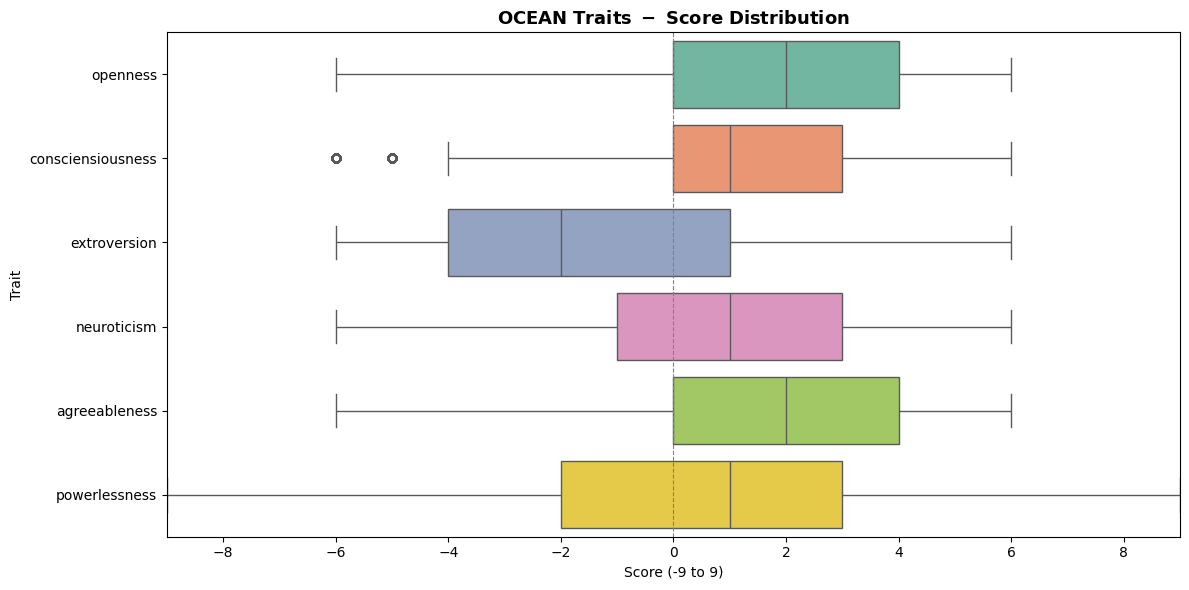

In [ ]:

ocean_cols = ['openness', 'consciensiousness', 'extroversion',
              'neuroticism', 'agreeableness', 'powerlessness']

# Reshape to long format for seaborn
long_data = non_cgl_df[ocean_cols].melt(var_name='trait', value_name='score')

# Plot horizontal box plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=long_data,
    y='trait',
    x='score',
    ax=ax,
    palette='Set2',
    showfliers=True,    # show outliers; set to False for a cleaner look
)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title(r"$\bf{OCEAN\ Traits\ -\ Score\ Distribution}$", fontsize=13)
ax.set_xlabel('Score (-9 to 9)')
ax.set_ylabel('Trait')
ax.set_xlim(-9, 9)

plt.tight_layout()
plt.show()



In [198]:
df.groupby('cgl_flag')[ocean_cols].describe().round(2)

openness                                      consciensiousness  \
            count  mean   std  min  25%  50%  75%  max             count   
cgl_flag                                                                   
False     12658.0  1.63  2.58 -6.0  0.0  2.0  4.0  6.0           12658.0   
True       2845.0  1.69  2.56 -6.0  0.0  2.0  4.0  6.0            2845.0   

                                             extroversion                   \
          mean  std  min  25%  50%  75%  max        count  mean   std  min   
cgl_flag                                                                     
False     1.28  2.4 -6.0  0.0  1.0  3.0  6.0      12658.0 -1.29  3.03 -6.0   
True      1.20  2.4 -6.0  0.0  1.0  3.0  6.0       2845.0 -1.30  3.03 -6.0   

                             neuroticism                                       \
          25%  50%  75%  max       count  mean   std  min  25%  50%  75%  max   
cgl_flag                                                                        
False    -4.0 -2.0  1.0  6.0     12658.0  0.95  2.66 -6.0 -1.0  1.0  3.0  6.0   
True     -4.0 -2.0  1.0  6.0      2845.0  1.02  2.69 -6.0  0.0  1.0  3.0  6.0   

         agreeableness                                      powerlessness  \
                 count  mean   std  min  25%  50%  75%  max         count   
cgl_flag                                                                    
False          12658.0  2.02  2.86 -6.0  0.0  2.0  4.0  6.0       12658.0   
True            2845.0  1.94  2.80 -6.0  0.0  2.0  4.0  6.0        2845.0   

                                               
          mean   std  min  25%  50%  75%  max  
cgl_flag                                       
False     0.64  3.60 -9.0 -2.0  1.0  3.0  9.0  
True      0.96  3.66 -9.0 -2.0  1.0  4.0  9.0

In [ ]:
ocean_cols = ['openness', 'consciensiousness', 'extroversion',
              'neuroticism', 'agreeableness', 'powerlessness']

# Per-trait full summary
summary = df[ocean_cols].agg(['mean', 'std', 'min', 'max']).round(2).T
summary['mean_as_pct_of_range'] = (summary['mean'] / 9 * 100).round(1)
print("=== Overall OCEAN distribution ===")
print(summary)

# By cgl_flag: mean, std, mean shift in standard-deviation units (Cohen's d)
print("\n=== By cgl_flag ===")
group_stats = df.groupby('cgl_flag')[ocean_cols].agg(['mean', 'std']).round(2)
print(group_stats.T)

# Cohen's d for each trait
print("\n=== Standardized differences (Cohen's d) ===")
d_results = []
for trait in ocean_cols:
    cgl = df.loc[(df['cgl_flag'] == True) & df[trait].notna(), trait]
    non_cgl = df.loc[(df['cgl_flag'] == False) & df[trait].notna(), trait]
    pooled_sd = ((cgl.std()**2 + non_cgl.std()**2) / 2) ** 0.5
    d = (cgl.mean() - non_cgl.mean()) / pooled_sd if pooled_sd else 0
    d_results.append({
        'trait': trait,
        'mean_non_cgl': round(non_cgl.mean(), 2),
        'mean_cgl': round(cgl.mean(), 2),
        'absolute_diff': round(cgl.mean() - non_cgl.mean(), 2),
        'cohens_d': round(d, 2),
    })
print(pd.DataFrame(d_results).set_index('trait'))


=== Overall OCEAN distribution ===
                   mean   std  min  max  mean_as_pct_of_range
openness           1.64  2.58 -6.0  6.0                  18.2
consciensiousness  1.27  2.40 -6.0  6.0                  14.1
extroversion      -1.29  3.03 -6.0  6.0                 -14.3
neuroticism        0.96  2.66 -6.0  6.0                  10.7
agreeableness      2.00  2.85 -6.0  6.0                  22.2
powerlessness      0.70  3.61 -9.0  9.0                   7.8

=== By cgl_flag ===
cgl_flag                False  True 
openness          mean   1.63   1.69
                  std    2.58   2.56
consciensiousness mean   1.28   1.20
                  std    2.40   2.40
extroversion      mean  -1.29  -1.30
                  std    3.03   3.03
neuroticism       mean   0.95   1.02
                  std    2.66   2.69
agreeableness     mean   2.02   1.94
                  std    2.86   2.80
powerlessness     mean   0.64   0.96
                  std    3.60   3.66

=== Standardized differences

In [ ]:
ocean_cols = ['openness', 'consciensiousness', 'extroversion',
              'neuroticism', 'agreeableness', 'powerlessness']

# Recompute Cohen's d (in case you don't already have it in scope)
results = []
for trait in ocean_cols:
    cgl = df.loc[(df['cgl_flag'] == True) & df[trait].notna(), trait]
    non_cgl = df.loc[(df['cgl_flag'] == False) & df[trait].notna(), trait]
    pooled_sd = ((cgl.std()**2 + non_cgl.std()**2) / 2) ** 0.5
    d = (cgl.mean() - non_cgl.mean()) / pooled_sd if pooled_sd else 0
    results.append({'trait': trait, 'd': round(d, 2),
                    'mean_cgl': round(cgl.mean(), 2),
                    'mean_non_cgl': round(non_cgl.mean(), 2)})

results_df = pd.DataFrame(results).set_index('trait')

def magnitude(d):
    a = abs(d)
    if a < 0.10:  return 'trivial'
    if a < 0.20:  return 'very small'
    if a < 0.50:  return 'small'
    if a < 0.80:  return 'medium'
    return 'large'

def direction(d):
    return 'higher' if d > 0 else 'lower'

# === Print summary ===
print("=" * 70)
print("OCEAN — CGL vs non-CGL: effect-size summary")
print("=" * 70)
print(f"\nSample sizes: CGL n={(df['cgl_flag']==True).sum():,}, "
      f"non-CGL n={(df['cgl_flag']==False).sum():,}\n")

# Table
print(results_df.assign(magnitude=results_df['d'].apply(magnitude)).to_string())

# Narrative
print("\n--- Narrative ---")
notable = results_df[results_df['d'].abs() >= 0.20].sort_values('d', key=abs, ascending=False)
trivial = results_df[results_df['d'].abs() < 0.10]

if len(notable):
    print("\nTraits with meaningful CGL/non-CGL differences (|d| ≥ 0.20):")
    for trait, row in notable.iterrows():
        print(f"  • {trait}: CGL users score {direction(row['d'])} "
              f"(d = {row['d']}, {magnitude(row['d'])} effect; "
              f"means {row['mean_cgl']} vs {row['mean_non_cgl']})")
else:
    print("\nNo OCEAN trait reached |d| ≥ 0.20 — differences between CGL and non-CGL")
    print("users are too small to be practically meaningful, even if statistically detectable.")

if len(trivial):
    print(f"\nTraits with no meaningful difference (|d| < 0.10): "
          f"{', '.join(trivial.index)}")


OCEAN — CGL vs non-CGL: effect-size summary

Sample sizes: CGL n=2,845, non-CGL n=12,658

                      d  mean_cgl  mean_non_cgl magnitude
trait                                                    
openness           0.02      1.69          1.63   trivial
consciensiousness -0.03      1.20          1.28   trivial
extroversion      -0.00     -1.30         -1.29   trivial
neuroticism        0.03      1.02          0.95   trivial
agreeableness     -0.03      1.94          2.02   trivial
powerlessness      0.09      0.96          0.64   trivial

--- Narrative ---

No OCEAN trait reached |d| ≥ 0.20 — differences between CGL and non-CGL
users are too small to be practically meaningful, even if statistically detectable.

Traits with no meaningful difference (|d| < 0.10): openness, consciensiousness, extroversion, neuroticism, agreeableness, powerlessness


We tested whether CGL identification is predicted by Big Five personality structure (Openness, Conscientiousness, Extraversion, Agreeableness, Neuroticism). Across all five OCEAN traits, standardized mean differences between CGL and non-CGL users were trivial (all |d| < 0.10), indicating that broad personality structure does not meaningfully differentiate CGL-identifying users from the rest of the sample. CGL identification appears to be orthogonal to personality as captured by the Big Five — it is better understood as a relational/behavioral preference than as a personality trait.

In [218]:
# 1. Powerlessness — not part of OCEAN, often correlates with kink/D-s dynamics
for col in ['powerlessness']:
    cgl = df.loc[df['cgl_flag'] == True, col].dropna()
    non_cgl = df.loc[df['cgl_flag'] == False, col].dropna()
    pooled_sd = ((cgl.std()**2 + non_cgl.std()**2) / 2) ** 0.5
    d = (cgl.mean() - non_cgl.mean()) / pooled_sd if pooled_sd else 0
    print(f"{col}: d = {d:.2f}")

# 2. Within-CGL personality differences — do caregivers vs littles differ?
within_cgl = cgl_df.groupby('soft_erotic_caretaker/caretakee dynamics')[ocean_cols].agg(['mean', 'std'])
print(within_cgl)

powerlessness: d = 0.09
                                          openness            \
                                              mean       std   
soft_erotic_caretaker/caretakee dynamics                       
0                                         1.658741  2.588395   
1                                         1.803136  2.467504   

                                         consciensiousness            \
                                                      mean       std   
soft_erotic_caretaker/caretakee dynamics                               
0                                                 1.196830  2.370990   
1                                                 1.221254  2.495686   

                                         extroversion           neuroticism  \
                                                 mean       std        mean   
soft_erotic_caretaker/caretakee dynamics                                      
0                                           -1.209159  3.

In [204]:
# 2. Within-CGL personality differences — do caregivers vs littles differ?
within_cgl = cgl_df.groupby('soft_erotic_caretaker/caretakee dynamics')[ocean_cols].agg(['mean', 'std'])
print(within_cgl)


                                          openness            \
                                              mean       std   
soft_erotic_caretaker/caretakee dynamics                       
0                                         1.658741  2.588395   
1                                         1.803136  2.467504   

                                         consciensiousness            \
                                                      mean       std   
soft_erotic_caretaker/caretakee dynamics                               
0                                                 1.196830  2.370990   
1                                                 1.221254  2.495686   

                                         extroversion           neuroticism  \
                                                 mean       std        mean   
soft_erotic_caretaker/caretakee dynamics                                      
0                                           -1.209159  3.025126    0.959489   
1 

In [208]:
# Map ordinal variety categories to numeric (1-7)
variety_7_map = {
    'Very narrow': 1,
    'A little narrow': 2,
    'Somewhat narrow': 3,
    'Equally narrow and broad': 4,
    'A little broad': 5,
    'Somewhat broad': 6,
    'Very broad': 7,
}
df['variety_num'] = df['sexual_interest_variety'].map(variety_7_map)

# Sanity check — make sure mapping covered all values
print("Mapped values:", df['variety_num'].value_counts(dropna=False).sort_index())
print("Unmapped (NaN):", df['variety_num'].isna().sum())

# OCEAN vs variety: Spearman correlation
print("\n=== OCEAN vs Sexual Interest Variety (Spearman ρ) ===")
for trait in ocean_cols:
    mask = df[trait].notna() & df['variety_num'].notna()
    r = df.loc[mask, trait].corr(df.loc[mask, 'variety_num'], method='spearman')
    print(f"  {trait:20s} ρ = {r:+.3f}")



Mapped values: variety_num
1.0     643
2.0    1754
3.0    1261
4.0    3159
5.0    2603
6.0    3687
7.0    2392
NaN       4
Name: count, dtype: int64
Unmapped (NaN): 4

=== OCEAN vs Sexual Interest Variety (Spearman ρ) ===
  openness             ρ = +0.085
  consciensiousness    ρ = +0.004
  extroversion         ρ = +0.070
  neuroticism          ρ = -0.041
  agreeableness        ρ = +0.023
  powerlessness        ρ = -0.048


In [209]:
# 1. Roles vs variety — is it about WHAT you're into, not WHO you are?
role_cols = df.filter(like='role_').columns.tolist()
for r in role_cols:
    rho = df[r].corr(df['variety_num'], method='spearman')
    print(f"  {r.replace('role_','')}: ρ = {rho:+.2f}")


  Atheletes: ρ = +0.10
  Babysitter: ρ = +0.13
  Catboys: ρ = +0.07
  Catgirls: ρ = +0.13
  Celebrities: ρ = +0.10
  Cheerleaders: ρ = +0.13
  Criminals: ρ = +0.08
  Doctors: ρ = +0.10
  Escorts/prostitutes: ρ = +0.13
  Geishas: ρ = +0.08
  Gigolos: ρ = +0.04
  Gynecologists: ρ = +0.06
  Librarians: ρ = +0.10
  Maids: ρ = +0.13
  Nuns: ρ = +0.11
  Nurses: ρ = +0.13
  Priests: ρ = +0.05
  Scientists: ρ = +0.09
  Strippers: ρ = +0.14
  Students: ρ = +0.14
  Teachers: ρ = +0.12


In [211]:
# 2. Caretaker/caretakee dynamic vs variety — is the D-s structure the predictor?
print(df.groupby('soft_erotic_caretaker/caretakee dynamics')['variety_num'].agg(['mean', 'median', 'std', 'count']))


                                              mean  median       std  count
soft_erotic_caretaker/caretakee dynamics                                   
0                                         4.651957     5.0  1.722743  13846
1                                         4.863884     5.0  1.692880   1653


In [212]:
# 3. Within-CGL: does caretaker vs caretakee differ on personality?
within_cgl = cgl_df.groupby('soft_erotic_caretaker/caretakee dynamics')[ocean_cols].mean().T
print(within_cgl)


soft_erotic_caretaker/caretakee dynamics         0         1
openness                                  1.658741  1.803136
consciensiousness                         1.196830  1.221254
extroversion                             -1.209159 -1.648084
neuroticism                               0.959489  1.259582
agreeableness                             1.856891  2.250871
powerlessness                             0.896081  1.207317


In [213]:
role_cols = df.filter(like='role_').columns.tolist()
role_variety = []
for r in role_cols:
    role_users = df.loc[df[r] == 1, 'variety_num'].dropna()
    non_role = df.loc[df[r] == 0, 'variety_num'].dropna()
    if len(role_users) > 30 and len(non_role) > 30:
        pooled_sd = ((role_users.std()**2 + non_role.std()**2) / 2) ** 0.5
        d = (role_users.mean() - non_role.mean()) / pooled_sd
        role_variety.append({
            'role': r.replace('role_', ''),
            'mean_with':  round(role_users.mean(), 2),
            'mean_without': round(non_role.mean(), 2),
            'd': round(d, 2),
            'n_with': len(role_users),
        })
import pandas as pd
print(pd.DataFrame(role_variety).sort_values('d', key=abs, ascending=False).to_string(index=False))


               role  mean_with  mean_without    d  n_with
Escorts/prostitutes       5.23          4.59 0.38    1999
            Geishas       5.28          4.65 0.38     709
               Nuns       5.26          4.62 0.38    1413
            Catboys       5.26          4.65 0.35     551
           Catgirls       5.16          4.59 0.34    2251
          Strippers       5.15          4.57 0.34    2706
       Cheerleaders       5.13          4.57 0.33    2966
           Students       5.10          4.56 0.32    3270
         Babysitter       5.11          4.58 0.31    2889
            Gigolos       5.21          4.67 0.31     177
             Nurses       5.08          4.57 0.30    3247
         Scientists       5.14          4.63 0.30    1320
              Maids       5.06          4.55 0.30    3691
        Celebrities       5.11          4.62 0.29    1771
          Atheletes       5.09          4.60 0.29    2301
         Librarians       5.09          4.61 0.28    2153
          Crim

In [214]:
df['n_roles'] = df[role_cols].sum(axis=1)
rho = df['n_roles'].corr(df['variety_num'], method='spearman')
print(f"Number of roles vs variety: ρ = {rho:.3f}")

Number of roles vs variety: ρ = 0.149


Variety preference is dose-dependent on role endorsement (ρ ≈ 0.X). Each additional role a respondent endorses corresponds to broader self-reported variety, regardless of role type. This suggests variety preference is best understood as a scalar measure of fantasy openness rather than a categorical kink-vs-vanilla distinction.

Variety preference isn't predicted by which role someone endorses — it's predicted by whether they endorse roles at all. The fact that single-role d is similar to or larger than total-role-count ρ is itself informative. It means "having any role" matters more than "having lots of roles." The relationship plateaus.

The fact that 21 different roles all produce ~0.3 effect sizes strongly suggests there's a single underlying construct doing the work: a general inclination toward role-based fantasy/play. The role columns are essentially measuring the same latent thing — "openness to role play" — and that latent thing is what correlates with variety.

The "0 vs any" boundary does most of the work — going from 0 to 1 role is a bigger jump than 1 to 5. The relationship may be non-linear.
People endorse multiple roles for reasons unrelated to variety — someone might have 8 roles all because they're into a specific aesthetic, not because they're "broad."

Compare effect sizes across all the things you've tested:

- Predictor of variety	Effect size
- Any single OCEAN trait	|ρ| ≤ 0.085 (trivial)
- CGL identification	d ≈ 0.10 (trivial)
- Caretaker dynamic	d ≈ 0.12 (trivial)
- Single role endorsement	d ≈ 0.23–0.38 (small)
- Number of roles endorsed	ρ = 0.15 (small, your best)


In [215]:
role_cols = df.filter(like='role_').columns.tolist()
df['n_roles'] = df[role_cols].sum(axis=1)

# Spearman: does endorsing more roles predict broader variety?
rho = df['n_roles'].corr(df['variety_num'], method='spearman')
print(f"n_roles vs variety: ρ = {rho:.3f}")

# Also: variety mean by number of roles
print("\nVariety by role count:")
print(df.groupby('n_roles')['variety_num'].agg(['mean', 'count']).round(2))


n_roles vs variety: ρ = 0.149

Variety by role count:
         mean  count
n_roles             
0        4.52  10111
1        4.70    102
2        4.39    224
3        4.60    339
4        4.74    424
5        4.68    514
6        4.75    487
7        4.94    519
8        4.97    487
9        5.14    484
10       5.00    397
11       5.17    356
12       5.34    264
13       5.22    225
14       5.45    192
15       5.53    115
16       5.36     91
17       5.51     67
18       5.76     37
19       5.55     31
20       5.86     14
21       5.68     19
